========== DATASET PREVIEW ==========
                                               Text                   Labels
0  Python programming and machine learning concepts  [Technology, Education]
1                Football world cup and sports news                 [Sports]
2           Latest smartphone and technology trends             [Technology]
3                 Health tips and fitness exercises                 [Health]
4              Artificial intelligence in education  [Technology, Education]

Dataset Shape: (12, 2)

Available Categories:
['Education' 'Health' 'Sports' 'Technology']

Number of Features: 46

Model Training Completed Successfully

========== MODEL EVALUATION ==========
Accuracy: 0.0 %

Classification Report:
              precision    recall  f1-score   support

   Education       0.00      0.00      0.00         1
      Health       0.00      0.00      0.00         1
      Sports       0.00      0.00      0.00         1
  Technology       0.33      1.00      0.50     

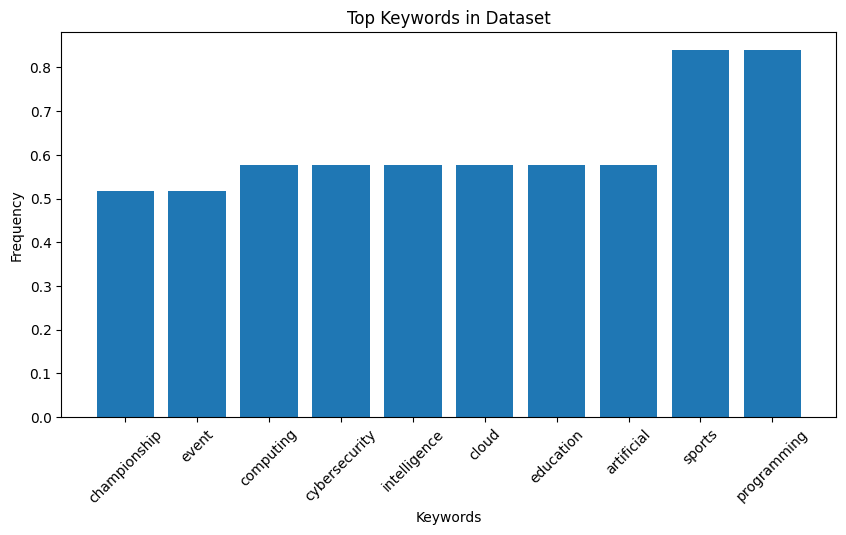


========== NEW TEXT PREDICTION ==========
Input Text:
Artificial intelligence and machine learning applications in education

Predicted Categories:
('Technology',)

========== SAMPLE PREDICTIONS ==========

Text: Football and cricket tournament news
Categories: ()

Text: Healthcare and fitness awareness program
Categories: ('Technology',)

Text: Programming, software development and AI
Categories: ('Technology',)


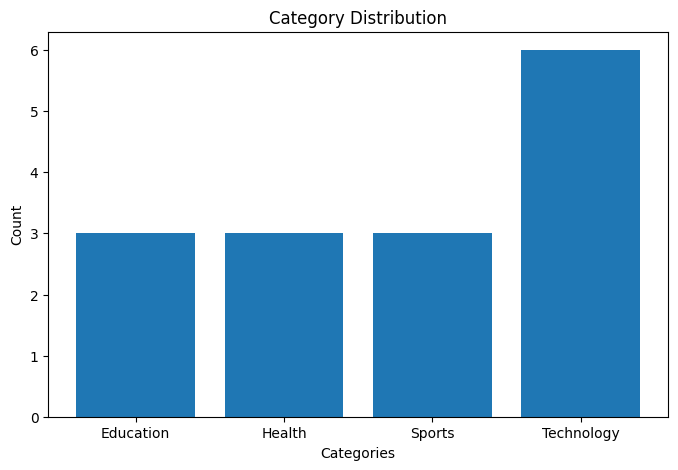


========== PROJECT SUMMARY ==========
Total Documents: 12
Total Categories: 4
Model Used: Logistic Regression
Text Vectorization: TF-IDF
Classification Type: Multi-Label Classification

Project Completed Successfully


In [3]:
# MULTI-LABEL TEXT CATEGORIZATION USING MACHINE LEARNING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Dataset
data = {
    'Text': [
        "Python programming and machine learning concepts",
        "Football world cup and sports news",
        "Latest smartphone and technology trends",
        "Health tips and fitness exercises",
        "Artificial intelligence in education",
        "Cricket match highlights and updates",
        "Data science and programming tutorials",
        "Healthy lifestyle and nutrition guide",
        "New software development techniques",
        "Basketball championship sports event",
        "Medical research and healthcare innovations",
        "Cloud computing and cybersecurity"
    ],

    'Labels': [
        ['Technology', 'Education'],
        ['Sports'],
        ['Technology'],
        ['Health'],
        ['Technology', 'Education'],
        ['Sports'],
        ['Technology', 'Education'],
        ['Health'],
        ['Technology'],
        ['Sports'],
        ['Health'],
        ['Technology']
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

print("========== DATASET PREVIEW ==========")
print(df.head())

# Dataset Information
print("\nDataset Shape:", df.shape)

# Convert Labels into Binary Format
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df['Labels'])

print("\nAvailable Categories:")
print(mlb.classes_)

# Convert Text into Numerical Features
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=100
)

X = tfidf.fit_transform(df['Text'])

print("\nNumber of Features:", X.shape[1])

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Build Model
model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000)
)

# Train Model
model.fit(X_train, y_train)

print("\nModel Training Completed Successfully")

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\n========== MODEL EVALUATION ==========")
print("Accuracy:", round(accuracy * 100, 2), "%")

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=mlb.classes_,
    zero_division=0
))

# Feature Analysis
feature_names = tfidf.get_feature_names_out()

word_frequency = np.asarray(X.sum(axis=0)).ravel()

top_indices = word_frequency.argsort()[-10:]

top_words = feature_names[top_indices]
top_counts = word_frequency[top_indices]

print("\n========== TOP KEYWORDS ==========")
for word, count in zip(top_words, top_counts):
    print(word, ":", round(count, 2))

# Visualization
plt.figure(figsize=(10,5))
plt.bar(top_words, top_counts)
plt.title("Top Keywords in Dataset")
plt.xlabel("Keywords")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

# New Text Prediction
print("\n========== NEW TEXT PREDICTION ==========")

new_text = [
    "Artificial intelligence and machine learning applications in education"
]

new_features = tfidf.transform(new_text)

prediction = model.predict(new_features)

predicted_labels = mlb.inverse_transform(prediction)

print("Input Text:")
print(new_text[0])

print("\nPredicted Categories:")
print(predicted_labels[0])

# Multiple Text Predictions
sample_texts = [
    "Football and cricket tournament news",
    "Healthcare and fitness awareness program",
    "Programming, software development and AI"
]

sample_features = tfidf.transform(sample_texts)

sample_predictions = model.predict(sample_features)

sample_labels = mlb.inverse_transform(sample_predictions)

print("\n========== SAMPLE PREDICTIONS ==========")

for text, labels in zip(sample_texts, sample_labels):
    print("\nText:", text)
    print("Categories:", labels)

# Category Distribution
category_counts = y.sum(axis=0)

plt.figure(figsize=(8,5))
plt.bar(mlb.classes_, category_counts)
plt.title("Category Distribution")
plt.xlabel("Categories")
plt.ylabel("Count")
plt.show()

print("\n========== PROJECT SUMMARY ==========")
print("Total Documents:", len(df))
print("Total Categories:", len(mlb.classes_))
print("Model Used: Logistic Regression")
print("Text Vectorization: TF-IDF")
print("Classification Type: Multi-Label Classification")

print("\nProject Completed Successfully")